In [3]:
import pandas as pd
import numpy as np

or_df = pd.read_csv("Integration_MelanomaData/integrated_data_melanoma.csv", index_col = 0)
fullDF = or_df
# fullDF = pd.read_csv("synthesizers/avatars/avatarsk10_42.csv")
# fullDF = pd.read_csv("gaussiancopula_42_BRDummy.csv")
fullDF = fullDF[or_df.columns.tolist()]
# with open("unexpressedGenes.txt", 'r', encoding='utf-8') as f:
#         # Đọc tất cả các dòng vào một list
#         raw_lines = f.readlines()

#     # Xử lý list để loại bỏ ký tự xuống dòng cho từng phần tử
# dropgenes_list = [line.strip() for line in raw_lines]

# fullDF = fullDF.drop(columns = dropgenes_list)

genelist = fullDF.iloc[:,54:].columns.tolist()
# generate response groups

responderCrit = fullDF['BR'].isin(['CR','PR'])
progressorCrit = fullDF['BR'].isin(['PD'])

responders = fullDF[responderCrit].index
progressors = fullDF[progressorCrit].index
nonresponders = fullDF[~responderCrit].index
nonprogressors = fullDF[~progressorCrit].index
print(len(responders),"responders")
print(len(progressors),"progressors")

fullDF.loc[responders,"PD vs Responder"] = 'Responder'
fullDF.loc[progressors,"PD vs Responder"] = 'Progressor'

fullDF.loc[responders,"Responder"] = 1
fullDF.loc[progressors,"Responder"] = 0

fullDF["PD vs nonPD"] = 'nonPD'
fullDF.loc[progressors,"PD vs nonPD"] = 'PD'

comparisonGroups = [
    'PD vs Responder',
    'PD vs nonPD',
]

fullDF['Responder'].value_counts()

47 responders
56 progressors


Responder
0.0    56
1.0    47
Name: count, dtype: int64

In [4]:
import math
# generate additional columns
fullDF['log nonsyn mutload'] = [math.log(abs(x+1e-9),10) for x in fullDF['nonsyn_muts']]
fullDF['log clonal mutload'] = [math.log(abs(x+1e-9),10) for x in fullDF['clonal_muts']]
fullDF['log subclonal mutload'] = [math.log(abs(x+1e-9),10) for x in fullDF['subclonal_muts']]
fullDF['log neoantigens'] = [math.log(abs(x+1e-9),10) for x in fullDF['total_neoantigens']]

# add additional category
fullDF.loc[fullDF.index, 'Primary_Type_Categ'] = "Skin or Occult"
mucosalCrit = fullDF['Primary_Type'] == "mucosal"
acralCrit = fullDF['Primary_Type'] == "acral"
fullDF.loc[mucosalCrit | acralCrit, 'Primary_Type_Categ'] = "Mucosal or Acral"

# add dominant mutational signature
uvDom = (fullDF['UV'] > fullDF['Alkylating']) & (fullDF['UV'] > fullDF['Cosmic'])
alkDom = (fullDF['Alkylating'] > fullDF['UV']) & (fullDF['Alkylating'] > fullDF['Cosmic'])
otherDom = (fullDF['Cosmic'] > fullDF['Alkylating']) & (fullDF['Cosmic'] > fullDF['UV'])

print(sum(uvDom), "tumors with dominant UV signature")
print(sum(alkDom), "tumors with dominant alkylating signature")
print(sum(otherDom), "tumors with dominant other (aging + others) signature")

# add to tumorDF
fullDF.loc[uvDom,"Dominant MutSig"] = 'UV'
fullDF.loc[alkDom,"Dominant MutSig"] = 'Alkylating'
fullDF.loc[otherDom,'Dominant MutSig'] = 'Other'

85 tumors with dominant UV signature
3 tumors with dominant alkylating signature
33 tumors with dominant other (aging + others) signature


In [3]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
style = "mac"
def TestMedian(v1, v2, VERBOSE = False, style = style):
    # try:
    test1 = [float(x) for x in v1 if not np.isnan(x)]
    test2 = [float(x) for x in v2 if not np.isnan(x)]
    # except:
    #     print(x)
    if len(v1) != len(test1) or len(v2) != len(test2): # nulls found
        if VERBOSE:
            print("WARNING: NULL values found in comparison groups and ignored")
        
    if style == "pc":
        (stat, pvalue) = mannwhitneyu(test1,test2, alternative = "two-sided")
    else: #  style = "mac"
        pvalue = mannwhitneyu(test1, test2)[1] * 2 # multiply by 2 to get two-sided p-value
    (meanstat, meanpvalue) = ttest_ind(test1, test2, equal_var = False)
    if VERBOSE:
        print("Group 1: median =", str(np.median(test1)), "mean = ", str(np.mean(test1)))
        print("Group 2: median =", str(np.median(test2)), "mean = ", str(np.mean(test2)))
        print("Mann Whitney rank test p-value is", pvalue, "T-test p-value = ", meanpvalue)
    diffMedian = np.median(test1) - np.median(test2)
    

    if diffMedian == 0:
        normDiffMedian = 0
    else:
        if np.median(test1 + test2) == 0:
            normalization = ((np.median(test1) + np.median(test2))/2.0)
        else:
            normalization = np.median(test1 +test2)
            
        normDiffMedian = diffMedian/normalization
        
    return pvalue, meanpvalue, normDiffMedian

responders_df = fullDF[fullDF["PD vs Responder"]=="Responder"]
progressor_df = fullDF[fullDF["PD vs Responder"]=="Progressor"]
pvalues = []
normDiffMedians = []

for gene in genelist:
    group1 = responders_df[gene].values
    group2 = progressor_df[gene].values
    pvalue, meanpvalue, normDiffMedian = TestMedian(group1, 
                            group2, 
                            VERBOSE=False, style = "pc")
    pvalues.append(pvalue)
    normDiffMedians.append(normDiffMedian)    
degs_results = {"Gene":genelist, "Pvalue": pvalues, "DiffMedian": normDiffMedians}
degs_df = pd.DataFrame(degs_results).set_index("Gene")

Text(0.5, 0, 'difference in medians (normalized)')

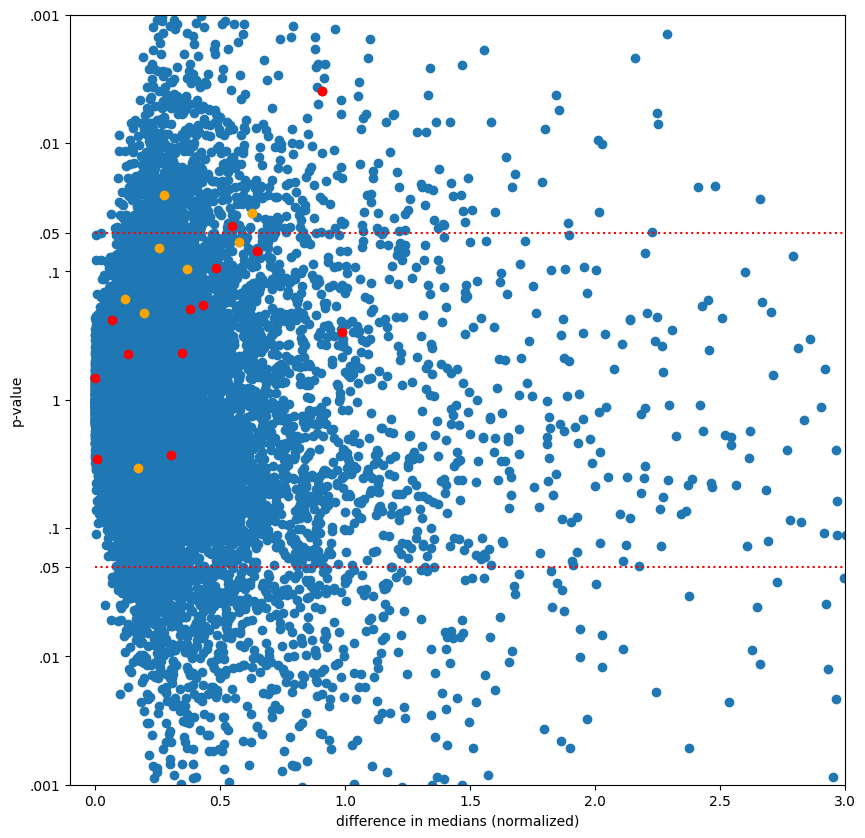

In [30]:
# Fig 2g - association of response with various transcriptomic features, highlighting mhc1 and mhc2 genes
# Plot neglogpval on y axis, difference in medians on the x axis
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
def PlotPValDiffs(df, ax = None, colorGenes = None, labelGenes = None):
    if ax == None:
        ax = plt.subplot()
      
    graphDF = df.copy()
    graphDF['neg log pval'] = [-math.log(x, 10) for x in df['pval']]
    responder = []
    signedMedDiff = []
    for x in df['median diffs']:
        if x > 0:
            responder += [1]
        else:
            responder += [-1]
        signedMedDiff += [abs(x)]
    graphDF['neg log pval'] = graphDF['neg log pval'] * responder
    graphDF['median diffs'] = signedMedDiff
    ax.scatter(graphDF['median diffs'], graphDF['neg log pval'])
    if colorGenes is not None:
        for color in colorGenes:
            ax.scatter(graphDF.loc[colorGenes[color], 'median diffs'], 
                       graphDF.loc[colorGenes[color], 'neg log pval'], 
                       color=color)

    ax.set_ylabel('p-value')
    ax.set_xlabel('difference in medians')
    
    sigY = -math.log(0.05,10)

    ax.set_yticks([-3,-2, -sigY, -1,0,1, sigY, 2,3])
    ax.set_yticklabels(['.001','.01', '.05', '.1','1','.1','.05','.01','.001'])
    
    # create red dotted line for significance
    sigY = -math.log(0.05,10)
    ax.plot([0,10],[sigY, sigY], color='red', linestyle=":")
    ax.plot([0,10],[-sigY, -sigY], color='red', linestyle=":")
    
    # label Points
    if labelGenes is not None:
        x = graphDF.loc[labelGenes,'median diffs']
        y = graphDF.loc[labelGenes,'neg log pval']
        for i in range(0,len(labelGenes)):
            x_offset = 3
            y_offset = 0.1
            ax.text(x[i] + x_offset,y[i] + y_offset, labelGenes[i])
            ax.plot([x[i], x[i] + x_offset],[y[i], y[i] + y_offset], color='black' )
    return ax
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5']

graphDF = degs_df[['Pvalue', 'DiffMedian']]

graphDF.columns = ['pval', 'median diffs']
fig = plt.figure(figsize=(10,10))
ax = plt.subplot()

colorGenes = {'red':mhc2,
             'orange':mhc1}

PlotPValDiffs(graphDF, ax = ax, colorGenes = colorGenes, labelGenes = None)
ax.set_xlim(-0.1,3)
ax.set_ylim(-3,3)
ax.set_xlabel('difference in medians (normalized)')

Text(0.5, 0, 'difference in medians (normalized)')

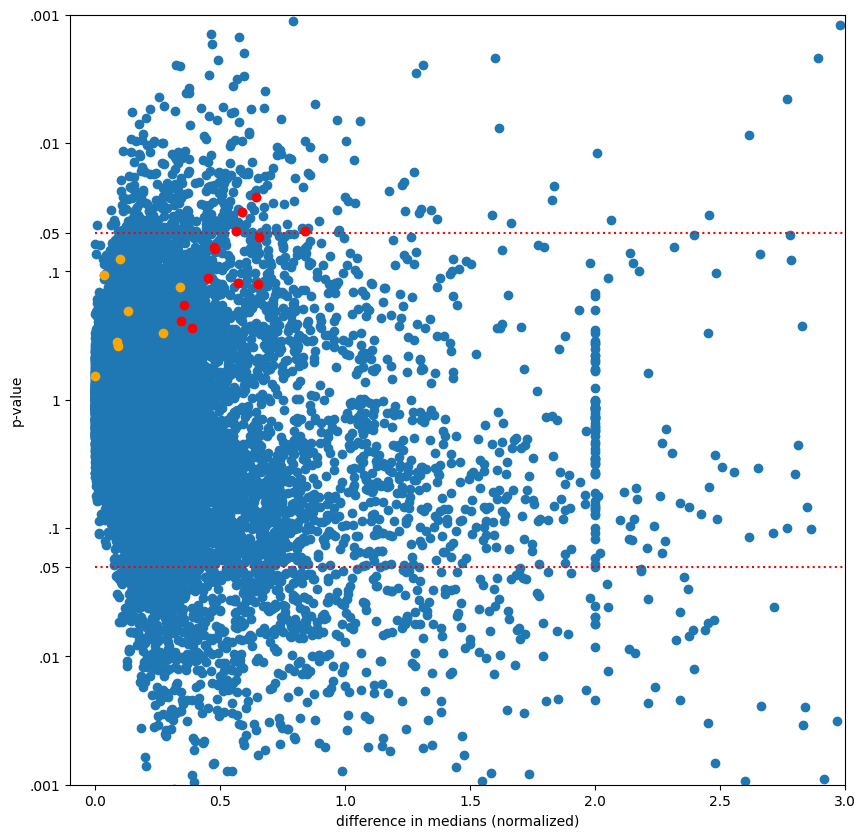

In [36]:
# Fig 2g - association of response with various transcriptomic features, highlighting mhc1 and mhc2 genes
# Plot neglogpval on y axis, difference in medians on the x axis
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
def PlotPValDiffs(df, ax = None, colorGenes = None, labelGenes = None):
    if ax == None:
        ax = plt.subplot()
      
    graphDF = df.copy()
    graphDF['neg log pval'] = [-math.log(x, 10) for x in df['pval']]
    responder = []
    signedMedDiff = []
    for x in df['median diffs']:
        if x > 0:
            responder += [1]
        else:
            responder += [-1]
        signedMedDiff += [abs(x)]
    graphDF['neg log pval'] = graphDF['neg log pval'] * responder
    graphDF['median diffs'] = signedMedDiff
    ax.scatter(graphDF['median diffs'], graphDF['neg log pval'])
    if colorGenes is not None:
        for color in colorGenes:
            ax.scatter(graphDF.loc[colorGenes[color], 'median diffs'], 
                       graphDF.loc[colorGenes[color], 'neg log pval'], 
                       color=color)

    ax.set_ylabel('p-value')
    ax.set_xlabel('difference in medians')
    
    sigY = -math.log(0.05,10)

    ax.set_yticks([-3,-2, -sigY, -1,0,1, sigY, 2,3])
    ax.set_yticklabels(['.001','.01', '.05', '.1','1','.1','.05','.01','.001'])
    
    # create red dotted line for significance
    sigY = -math.log(0.05,10)
    ax.plot([0,10],[sigY, sigY], color='red', linestyle=":")
    ax.plot([0,10],[-sigY, -sigY], color='red', linestyle=":")
    
    # label Points
    if labelGenes is not None:
        x = graphDF.loc[labelGenes,'median diffs']
        y = graphDF.loc[labelGenes,'neg log pval']
        for i in range(0,len(labelGenes)):
            x_offset = 3
            y_offset = 0.1
            ax.text(x[i] + x_offset,y[i] + y_offset, labelGenes[i])
            ax.plot([x[i], x[i] + x_offset],[y[i], y[i] + y_offset], color='black' )
    return ax
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5']

graphDF = degs_df[['Pvalue', 'DiffMedian']]

graphDF.columns = ['pval', 'median diffs']
fig = plt.figure(figsize=(10,10))
ax = plt.subplot()

colorGenes = {'red':mhc2,
             'orange':mhc1}

PlotPValDiffs(graphDF, ax = ax, colorGenes = colorGenes, labelGenes = None)
ax.set_xlim(-0.1,3)
ax.set_ylim(-3,3)
ax.set_xlabel('difference in medians (normalized)')

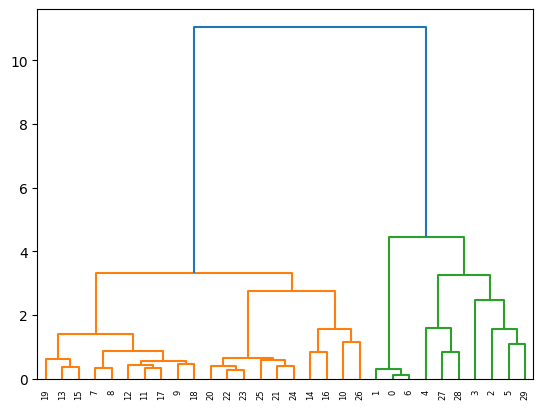

In [5]:
# Fig 2h - hierarchical clustering of genomic and transcriptomic features
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

comparators = [
            'log nonsyn mutload',
             'log clonal mutload',
              'heterogeneity',
              'purity',
                'ploidy',
             'CNA_prop',
               'log neoantigens',
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5',
            'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'TAP1', 'TAP2', 'B2M',
            'MHCI_Amp',
            'TAP2_Amp',
               'Tx_Start_LDH',
                ]
# Generate the co-correlation matrix and hierarchical clustering based on heat map

features = comparators

# generate the correlations for features in tumorDF first
tumorDFFeatures = [x for x in features if x in fullDF.columns]

tumorDFCorr = pd.DataFrame(columns = tumorDFFeatures)
for feature in tumorDFFeatures:
    tumorDFCorr[feature] = pd.to_numeric(fullDF[feature], errors="coerce") # coerce to numerics
    
tumorDFcorrmat = tumorDFCorr.corr()

corrDF = pd.DataFrame(columns = features)
for feature in features:
    corrDF[feature] = pd.to_numeric(fullDF[feature], errors="coerce") # coerce to numerics
corrmat = corrDF.corr() 

for feature in tumorDFFeatures: # replace entries where they exist
    for feature2 in tumorDFFeatures:
        corrmat.loc[feature, feature2] = tumorDFcorrmat.loc[feature, feature2]

#corrmat = batch1fullDF.ix[cbTest+ncbTest, numericFeatures].corr()
Z = linkage(corrmat, 'ward') # generate the linkage/hierarchical clustering
order = [int(s) for s in dendrogram(Z, leaf_rotation=90, leaf_font_size=6)['ivl']]

In [ ]:
# define groups
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = [
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
    'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
    'HLA-DRB5'
]

# colors for the groups (choose your palette)
group_colors = {
    "mhc1": "#1f77b4",    # blue
    "mhc2": "#ff7f0e",    # orange
    "other": "#d3d3d3"    # light gray
}

# Make sure order exists
ordered_cols = corrmat.index[order]

# Build a color list aligned with ordered_cols
col_colors = []
for col in ordered_cols:
    if col in mhc1:
        col_colors.append(group_colors["mhc1"])
    elif col in mhc2:
        col_colors.append(group_colors["mhc2"])
    else:
        col_colors.append(group_colors["other"])

# Create clustermap with colored strips for rows and columns
cg = sns.clustermap(
    corrmat.loc[ordered_cols, ordered_cols],
    cmap="coolwarm",
    center=0,
    row_colors=col_colors,
    col_colors=col_colors,
    linewidths=0,
    figsize=(12, 12)
)

# Improve label rotation / font size
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=10)
plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)

# Add legend for colored groups (attach to the figure)
patches = [
    mpatches.Patch(color=group_colors["mhc1"], label="MHC-I"),
    mpatches.Patch(color=group_colors["mhc2"], label="MHC-II"),
    mpatches.Patch(color=group_colors["other"], label="Other")
]
# place legend to the right of the heatmap
# cg.fig.legend(handles=patches, loc="upper right", bbox_to_anchor=(0.99, 0.8))

plt.show()